# Latent Collective State Discovery (Expanded Feature Set)

Discovers latent interaction states using multimodal 30-second window features across all 10 groups, tasks T1–T3.

**Feature sets:**
- Physio: HR, HRV, EDA tonic/phasic, temperature (+ within-group spread)
- Transcript: speaking density, silence, backchannels, overlap subtypes, entropy, conflict ratio
- Eye-tracking: pupil, blink rate, gaze dispersion
- **NEW — BERT-UMAP**: semantic topic dimensions (5 dims)
- **NEW — Keyword DA**: dialogue act profiles (hedge, question, backchannel, statement, agreement)
- **NEW — Semantic continuity**: cosine similarity between consecutive speakers

**K selection:** BIC on GaussianMixture (primary) + K-Means silhouette (secondary)

**Pipeline:**
1. Load + merge all feature files
2. Impute + standardise
3. PCA for dimensionality reduction
4. K selection via BIC
5. K-Means (initialises GMM)
6. Gaussian HMM via Viterbi decoding
7. State characterisation + self-report validation
8. Export state proportions → `hmm_state_proportions_expanded.tsv`

> **Privacy:** All participant references use P1–P4 IDs only.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT = Path("..")
WINDOW_FILE     = ROOT / "analysis" / "results" / "collective_features_v20260812" / "collective_window_features.tsv"
SELFREPORT_FILE = ROOT / "analysis" / "results" / "collective_features_v20260812" / "collective_task_selfreport.tsv"
NLP_FILES = {
    "bert":     ROOT / "analysis" / "results" / "bert_embeddings_window_30s.tsv",
    "kw_da":    ROOT / "analysis" / "results" / "da_keyword_window_30s.tsv",
    "nli_da":   ROOT / "analysis" / "results" / "da_window_30s.tsv",
    "sem":      ROOT / "analysis" / "results" / "semantic_continuity_window_30s.tsv",
}

# ── Visual settings ────────────────────────────────────────────────────────────
# Dynamic colours for all groups
import matplotlib.cm as _cm
_all_grps = [f"grp-{i:02d}" for i in [7,8,9,10,11,12,13,14,15,16]]
_colors = _cm.tab10.colors
GROUP_COLORS = {g: f"#{int(r*255):02x}{int(g2*255):02x}{int(b*255):02x}" for g,(r,g2,b,*_) in zip(_all_grps, _colors)}
TASK_MARKERS = {"T1": "o", "T2": "s", "T3": "^"}  
print("Imports OK")

Imports OK


## 1. Load Data

In [2]:
windows = pd.read_csv(WINDOW_FILE, sep="\t")
selfreport = pd.read_csv(SELFREPORT_FILE, sep="\t")

print(f"Window features : {windows.shape[0]} rows × {windows.shape[1]} cols")
print(f"Self-report     : {selfreport.shape[0]} rows × {selfreport.shape[1]} cols")
print(f"\nGroups  : {sorted(windows['group_id'].unique())}")
print(f"Tasks   : {sorted(windows['task_id'].unique())}")
windows.head(3)
# ── Merge NLP features (BERT, DA, semantic continuity) ───────────────────────
_KEY = ['group_id', 'task_id', 'window_index']
for _name, _fpath in NLP_FILES.items():
    if _fpath.exists():
        _df = pd.read_csv(_fpath, sep='\t')
        _merge_cols = [c for c in _df.columns if c not in windows.columns or c in _KEY]
        windows = windows.merge(_df[_merge_cols], on=_KEY, how='left')
        print(f'  Merged {_name}: {len([c for c in _merge_cols if c not in _KEY])} new cols')
    else:
        print(f'  Skipped {_name}: file not found')
print(f'Extended window matrix: {windows.shape}')


# -- Preprocessing (applied to windows DataFrame before feature selection) -----
# Physio & pupil: within-group z-score removes between-group baseline offsets.
# These are the right transforms for group-level physio (ICMI paper approach).
PHYSIO_Z_COLS = [
    'group_hr_mean_bpm_mean',        # raw skew=3.5 — between-group offset is main issue
    'group_eda_phasic_rate_hz_mean',
    'group_hrv_rmssd_ms_mean',
    'group_eda_tonic_mean_mean',     # raw skew=3.2 — between-group offset is main issue
    'group_temp_mean_mean',
    'group_et_pupil_mean_mean',
]
for col in PHYSIO_Z_COLS:
    if col in windows.columns:
        windows[col] = windows.groupby('group_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9))

# Count/rate features: log1p to reduce right skew before z-score standardisation
LOG_COLS = [
    'tr_silence_duration_s',     # skew=6.9
    'tr_overlap_count',          # skew=2.5
    'tr_competitive_overlap',    # skew=3.0
    'tr_laughter_count',         # skew=3.0
    'tr_backchannel_count',      # skew=1.7
    # Lexical count/rate features
    'lex_social_composite',      # skew=4.9
    'lex_dm_elaboration',        # skew=1.7
    'lex_turn_cohesion',         # skew=1.6
    'lex_hedging_count',         # skew=0.9
    'lex_we_i_ratio',            # skew=0.7 (ratio — log1p compresses outliers)
    # Context overlap types — log1p same as tr_competitive_overlap
    'tr_cooperative_overlap',
    'tr_collaborative_overlap',
]
for col in LOG_COLS:
    if col in windows.columns:
        windows[col] = np.log1p(windows[col].clip(lower=0))

print("Preprocessing applied:")
print(f"  Within-group z-score: {[c for c in PHYSIO_Z_COLS if c in windows.columns]}")
print(f"  Log1p: {[c for c in LOG_COLS if c in windows.columns]}")


Window features : 1580 rows × 59 cols
Self-report     : 30 rows × 30 cols

Groups  : ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
Tasks   : ['T1', 'T2', 'T3']
  Merged bert: 12 new cols
  Merged kw_da: 13 new cols
  Merged nli_da: 1 new cols
  Merged sem: 2 new cols
Extended window matrix: (1580, 87)
Preprocessing applied:
  Within-group z-score: ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_hrv_rmssd_ms_mean', 'group_eda_tonic_mean_mean', 'group_temp_mean_mean', 'group_et_pupil_mean_mean']
  Log1p: ['tr_silence_duration_s', 'tr_overlap_count', 'tr_competitive_overlap', 'tr_laughter_count', 'tr_backchannel_count', 'tr_cooperative_overlap', 'tr_collaborative_overlap']


## 2. Feature Selection & Preprocessing

We select the **core multimodal features** for state discovery:
- **Physio (group-level):** mean HR, HRV, EDA tonic, EDA phasic, temperature + within-group spread (std)
- **Transcript interaction:** speaking density, silence, backchannels, overlap (total), overlap subtype mix (competitive/cooperative/collaborative/needs_review), active speakers, entropy, conflict ratio
- **ET (group-level):** mean pupil diameter, blink rate, gaze dispersion

Windows with no transcript data are dropped (outer-join artefacts). Remaining NaN values are mean-imputed per column.

In [3]:
# HMM feature set — 19 features across 4 modalities
#
# PHYSIO (6): all within-group z-scored — removes between-group baselines
# TRANSCRIPT (7): ICMI core features + speaking_entropy
# CONTEXT OVERLAP (2): cooperative + collaborative overlap (tentative — not fully validated)
# LEXICAL HOW (4): linguistic style features only — no topic content
#
# Excluded from HMM (post-hoc characterization / prediction models only):
#   DA features, BERT-UMAP, lex_ttr, lex_vader_compound, lex_dm_elaboration,
#   lex_social_composite, semantic continuity, completion/repetition

PHYSIO_FEATURES = [
    "group_hr_mean_bpm_mean",          # within-group z-scored
    "group_eda_phasic_rate_hz_mean",   # within-group z-scored
    "group_hrv_rmssd_ms_mean",         # within-group z-scored
    "group_eda_tonic_mean_mean",       # within-group z-scored
    "group_temp_mean_mean",            # within-group z-scored
    "group_et_pupil_mean_mean",        # within-group z-scored (ICMI)
]
TRANSCRIPT_FEATURES = [
    "tr_silence_duration_s",           # log1p — silence within the window
    "tr_backchannel_count",            # log1p
    "tr_overlap_count",                # log1p
    "tr_competitive_overlap",          # log1p — KEY discriminative feature
    "tr_laughter_count",               # log1p
    "tr_n_active_speakers",
    "tr_speaking_entropy",
]
CONTEXT_OVERLAP_FEATURES = [
    "tr_cooperative_overlap",          # log1p — context-labeled (tentative)
    "tr_collaborative_overlap",        # log1p — context-labeled (tentative)
]
LEXICAL_FEATURES = [
    "lex_word_gini",                   # participation inequality (HOW, not WHAT)
    "lex_we_i_ratio",                  # log1p — collective vs individual framing
    "lex_turn_cohesion",               # log1p — lexical flow between turns
    "lex_hedging_count",               # log1p — uncertainty / tentativeness
]

# Merge lexical file
_lex_path = ROOT / "analysis" / "results" / "lexical_window_30s.tsv"
if _lex_path.exists():
    _lex = pd.read_csv(_lex_path, sep="\t")
    _lex_merge = [c for c in _lex.columns
                  if c not in windows.columns or c in ["group_id","task_id","window_index"]]
    windows = windows.merge(_lex[_lex_merge], on=["group_id","task_id","window_index"], how="left")

# Post-hoc characterization features (NOT in HMM — computed over valid windows per state)
NLP_CHAR_FEATURES = [c for c in [
    "da_hedge", "da_question", "da_backchannel", "da_statement", "da_agreement",
    "da_disagreement", "da_compromise", "da_offtask",
    "bert_umap1", "bert_umap2", "bert_umap3",
    "lex_vader_compound", "lex_ttr", "lex_dm_elaboration", "lex_social_composite",
] if c in windows.columns]

ALL_FEATURES = [c for c in
    PHYSIO_FEATURES + TRANSCRIPT_FEATURES + CONTEXT_OVERLAP_FEATURES + LEXICAL_FEATURES
    if c in windows.columns]

print(f"HMM feature set: {len(ALL_FEATURES)} features")
print(f"  Physio+ET: {sum(c in windows.columns for c in PHYSIO_FEATURES)}")
print(f"  Transcript timing: {sum(c in windows.columns for c in TRANSCRIPT_FEATURES)}")
print(f"  Context overlap: {sum(c in windows.columns for c in CONTEXT_OVERLAP_FEATURES)}")
print(f"  Lexical HOW: {sum(c in windows.columns for c in LEXICAL_FEATURES)}")
print(f"  Post-hoc char features available: {len(NLP_CHAR_FEATURES)}")


HMM feature set: 19 features
  Physio+ET: 6
  Transcript timing: 7
  Context overlap: 2
  Lexical HOW: 4
  Post-hoc char features available: 15


In [4]:
# ── Filter: trim leading/trailing silence per group×task ──────────────────────
# Remove only structured individual-work phases at the START and END of each
# task sequence. Interior silence windows (genuine discussion pauses) are kept.

df = windows.dropna(subset=["tr_spk_duration_s"]).copy()
n_all = len(df)

silence_props = (
    df.assign(_s=(df["tr_spk_duration_s"] == 0).astype(int))
    .groupby(["group_id", "task_id"])
    .agg(prop_silent_windows=("_s", "mean"))
    .reset_index()
)

parts = []
for (grp, task), gdf in df.groupby(["group_id", "task_id"]):
    active_idx = gdf.loc[gdf["tr_spk_duration_s"] > 0, "window_index"]
    if active_idx.empty:
        continue
    parts.append(gdf[(gdf["window_index"] >= active_idx.min()) &
                     (gdf["window_index"] <= active_idx.max())])
df = pd.concat(parts, ignore_index=True)

n_interior_silent = (df["tr_spk_duration_s"] == 0).sum()
print(f"Windows after boundary trim: {len(df)} / {n_all}")
print(f"  Interior silence windows kept: {n_interior_silent}")

miss = df[ALL_FEATURES].isna().mean().sort_values(ascending=False)
if miss[miss > 0].any():
    print("Residual missing (sensor gaps):")
    print(miss[miss > 0].round(3).to_string())

keep = [c for c in ALL_FEATURES if df[c].isna().mean() <= 0.4]
ALL_FEATURES = keep

imputer = SimpleImputer(strategy="mean")
X_raw = imputer.fit_transform(df[ALL_FEATURES])

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

meta = df[["group_id", "task_id", "window_index", "window_start_s"]].reset_index(drop=True)
print(f"Final feature matrix: {X.shape}")


Windows after boundary trim: 568 / 717
  Interior silence windows kept: 54
Residual missing (sensor gaps):
lex_we_i_ratio                   0.180
lex_turn_cohesion                0.157
group_hrv_rmssd_ms_mean          0.125
lex_word_gini                    0.097
group_et_pupil_mean_mean         0.081
group_eda_phasic_rate_hz_mean    0.042
group_hr_mean_bpm_mean           0.042
group_eda_tonic_mean_mean        0.042
Final feature matrix: (568, 19)



=== Feature coverage & variance ===
                      feature  coverage_pct  std_raw
               lex_we_i_ratio          82.0    0.322
            lex_turn_cohesion          84.3    0.064
      group_hrv_rmssd_ms_mean          87.5    0.996
                lex_word_gini          90.3    0.147
     group_et_pupil_mean_mean          91.9    0.969
       group_hr_mean_bpm_mean          95.8    1.020
    group_eda_tonic_mean_mean          95.8    0.794
group_eda_phasic_rate_hz_mean          95.8    0.919
         tr_backchannel_count         100.0    0.638
             tr_overlap_count         100.0    0.688
            tr_laughter_count         100.0    0.419
       tr_competitive_overlap         100.0    0.530
         tr_n_active_speakers         100.0    1.155
          tr_speaking_entropy         100.0    0.588
        tr_silence_duration_s         100.0    1.038
         group_temp_mean_mean         100.0    0.964
     tr_collaborative_overlap         100.0    0.395
       tr

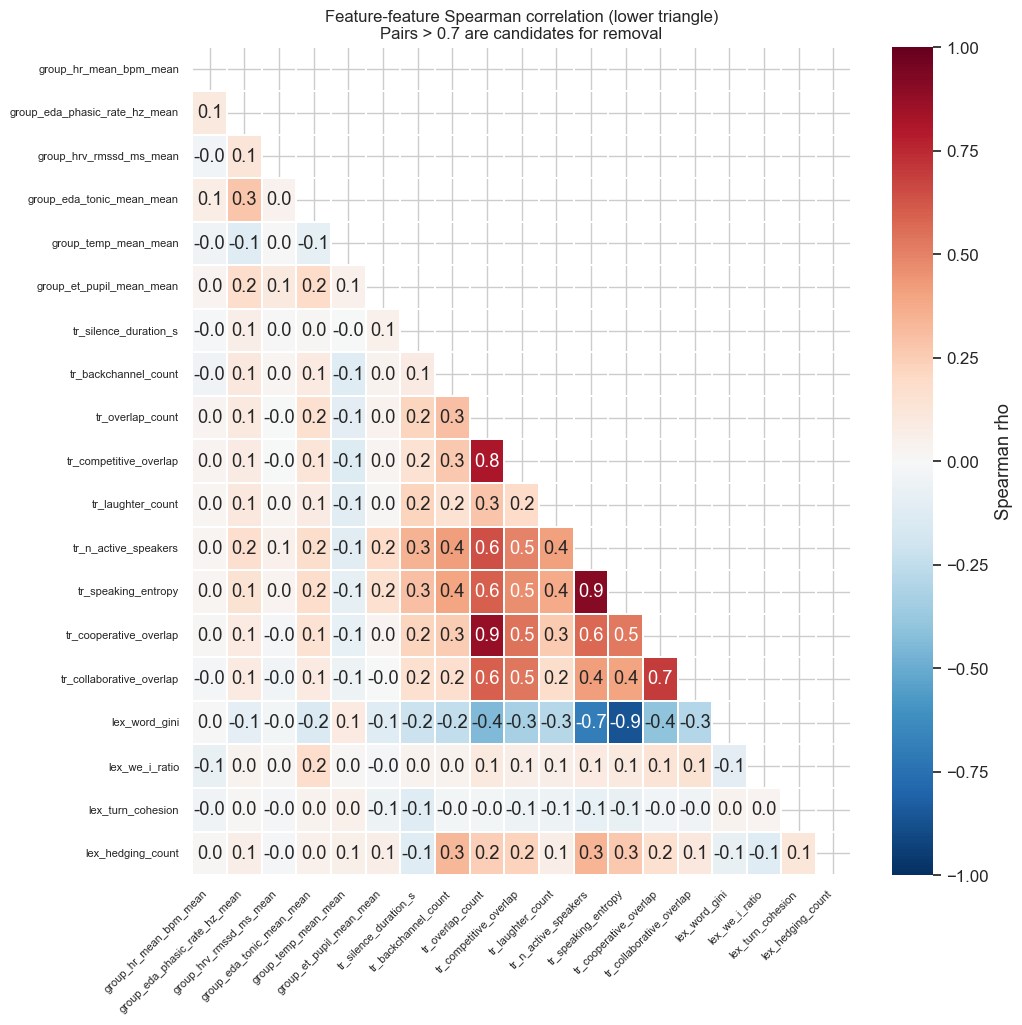


=== Highly correlated pairs (|rho| > 0.70): 4 ===
           feature_A              feature_B   rho
tr_n_active_speakers    tr_speaking_entropy  0.91
    tr_overlap_count tr_cooperative_overlap  0.87
 tr_speaking_entropy          lex_word_gini -0.86
    tr_overlap_count tr_competitive_overlap  0.81


In [5]:
# Feature audit: coverage, variance, pairwise Spearman correlation
# Use this output to decide which features to drop before re-running the model.

feat_audit = pd.DataFrame({
    'feature': ALL_FEATURES,
    'coverage_pct': [round((1 - df[c].isna().mean()) * 100, 1) for c in ALL_FEATURES],
    'std_raw': df[ALL_FEATURES].std().round(3).values,
}).sort_values('coverage_pct')

print("\n=== Feature coverage & variance ===")
print(feat_audit.to_string(index=False))

# Spearman correlation heatmap (use imputed X matrix)
feat_df_audit = pd.DataFrame(X, columns=ALL_FEATURES)
corr = feat_df_audit.corr(method='spearman')

fig, ax = plt.subplots(figsize=(max(10, len(ALL_FEATURES)*0.55), max(8, len(ALL_FEATURES)*0.55)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=(len(ALL_FEATURES) <= 20), fmt='.1f', linewidths=0.3,
            ax=ax, cbar_kws={'label': 'Spearman rho'})
ax.set_title('Feature-feature Spearman correlation (lower triangle)\n'
             'Pairs > 0.7 are candidates for removal', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

# Highlight highly correlated pairs (|rho| > 0.7)
high_corr = []
for i, c1 in enumerate(ALL_FEATURES):
    for j, c2 in enumerate(ALL_FEATURES):
        if j <= i: continue
        r = corr.loc[c1, c2]
        if abs(r) > 0.70:
            high_corr.append({'feature_A': c1, 'feature_B': c2, 'rho': round(r, 2)})
if high_corr:
    print(f"\n=== Highly correlated pairs (|rho| > 0.70): {len(high_corr)} ===")
    print(pd.DataFrame(high_corr).sort_values('rho', key=abs, ascending=False).to_string(index=False))
else:
    print("\nNo feature pairs with |rho| > 0.70")


## 3. PCA — Dimensionality Reduction & Exploration

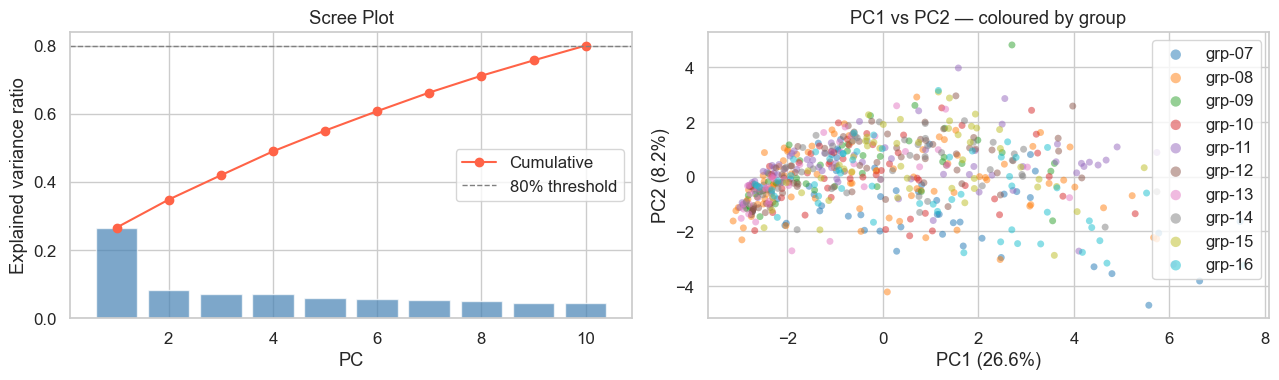

PCs needed to reach 80% variance: 10


In [6]:
pca = PCA(n_components=min(10, len(ALL_FEATURES)))
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_, color="steelblue", alpha=0.7)
axes[0].plot(range(1, len(cumvar)+1), cumvar, "o-", color="tomato", label="Cumulative")
axes[0].axhline(0.80, ls="--", color="gray", lw=1, label="80% threshold")
axes[0].set_xlabel("PC"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree Plot"); axes[0].legend()

# PC1 vs PC2 coloured by group
for grp, grp_meta in meta.groupby("group_id"):
    idx = grp_meta.index
    axes[1].scatter(X_pca[idx, 0], X_pca[idx, 1],
                    c=GROUP_COLORS.get(grp, "gray"), label=grp,
                    alpha=0.5, s=25, edgecolors="none")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PC1 vs PC2 — coloured by group")
axes[1].legend(markerscale=1.5)

plt.tight_layout()
plt.show()

n_pcs = int(np.searchsorted(cumvar, 0.80)) + 1
print(f"PCs needed to reach 80% variance: {n_pcs}")
X_reduced = X_pca[:, :n_pcs]

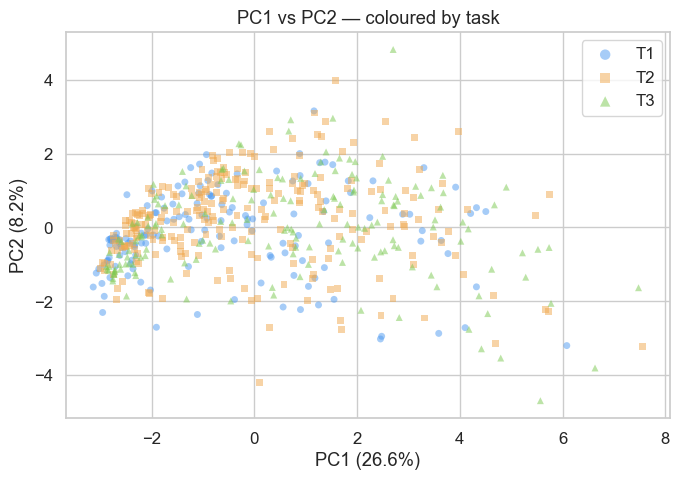

In [7]:
# PC1 vs PC2 coloured by task
task_colors = {"T1": "#4e9af1", "T2": "#f1a94e", "T3": "#7bc950"}
fig, ax = plt.subplots(figsize=(7, 5))
for task, t_meta in meta.groupby("task_id"):
    idx = t_meta.index
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=task_colors.get(task, "gray"), label=task,
               alpha=0.5, s=25, marker=TASK_MARKERS.get(task, "o"),
               edgecolors="none")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PC1 vs PC2 — coloured by task")
ax.legend(markerscale=1.5)
plt.tight_layout(); plt.show()

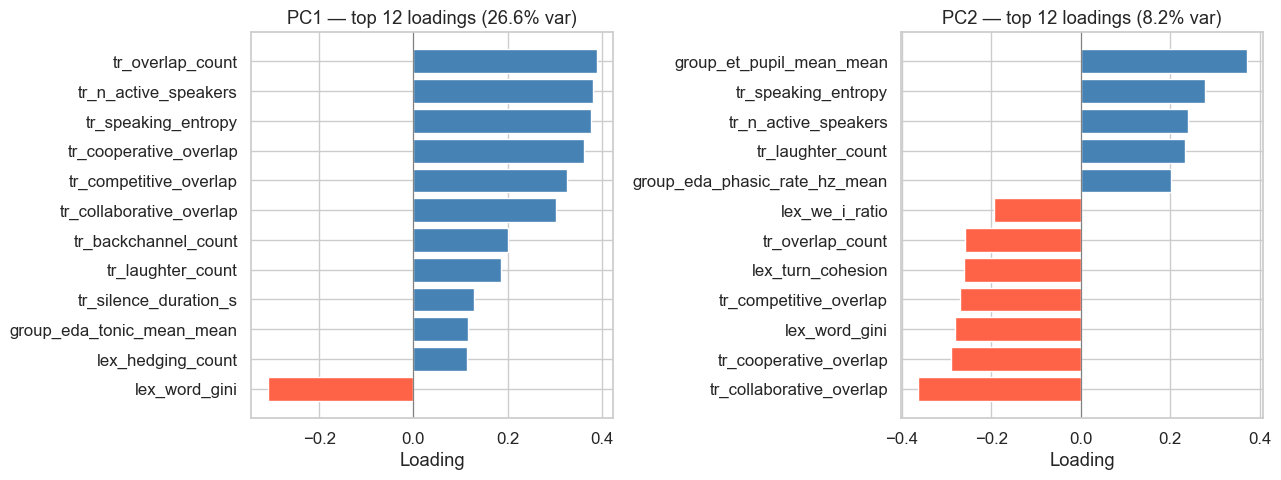

In [8]:
# Feature loadings on PC1 and PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=ALL_FEATURES,
    columns=["PC1", "PC2"]
).sort_values("PC1")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, pc in enumerate(["PC1", "PC2"]):
    top = loadings[pc].abs().nlargest(12).index
    vals = loadings.loc[top, pc].sort_values()
    colors = ["tomato" if v < 0 else "steelblue" for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors)
    axes[i].axvline(0, color="gray", lw=0.8)
    axes[i].set_title(f"{pc} — top 12 loadings ({pca.explained_variance_ratio_[i]:.1%} var)")
    axes[i].set_xlabel("Loading")

plt.tight_layout(); plt.show()

## 4. K-Means Clustering

We evaluate k = 2–8 using the **elbow (inertia)** and **silhouette score**, then fit the chosen k.

✓ GaussianHMM class defined
Sequences: 28, total windows: 568
  k=2  BIC=17447.5  logL=-8581.0
  k=3  BIC=17247.0  logL=-8398.4
  k=4  BIC=17139.3  logL=-8255.7
  k=5  BIC=17290.0  logL=-8235.9
  k=6  BIC=17214.3  logL=-8096.6

BIC-optimal k: 4

BIC values:
  k=2  BIC=17447.5
  k=3  BIC=17247.0
  k=4  BIC=17139.3 <- minimum
  k=5  BIC=17290.0
  k=6  BIC=17214.3

K-Means k=4 distribution:
kmeans_state
0    170
1    130
2     72
3    196
Name: count, dtype: int64


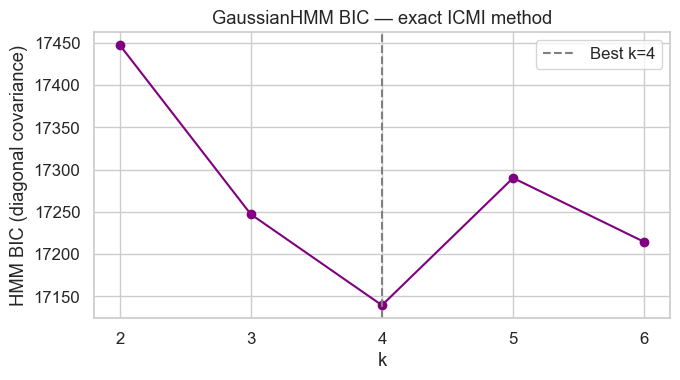

In [16]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

class GaussianHMM:
    """Diagonal-covariance Gaussian HMM with Baum-Welch EM."""
    
    def __init__(self, n_states=3, n_iter=100, tol=1e-4, random_state=42):
        self.K = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)
    
    def _log_emit(self, X):
        T, D = X.shape
        log_p = np.zeros((T, self.K))
        for k in range(self.K):
            log_p[:, k] = multivariate_normal.logpdf(X, mean=self.means_[k],
                                                      cov=np.diag(self.covs_[k]))
        return log_p
    
    def _forward(self, log_emit):
        T, K = log_emit.shape
        log_alpha = np.full((T, K), -np.inf)
        log_alpha[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        log_A = np.log(self.A_ + 1e-300)
        for t in range(1, T):
            for k in range(K):
                log_alpha[t, k] = logsumexp(log_alpha[t-1] + log_A[:, k]) + log_emit[t, k]
        return log_alpha
    
    def _backward(self, log_emit):
        T, K = log_emit.shape
        log_beta = np.zeros((T, K))
        log_A = np.log(self.A_ + 1e-300)
        for t in range(T-2, -1, -1):
            for k in range(K):
                log_beta[t, k] = logsumexp(log_A[k] + log_emit[t+1] + log_beta[t+1])
        return log_beta
    
    def _viterbi(self, log_emit):
        T, K = log_emit.shape
        log_A = np.log(self.A_ + 1e-300)
        delta = np.full((T, K), -np.inf)
        psi = np.zeros((T, K), dtype=int)
        delta[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        for t in range(1, T):
            for k in range(K):
                scores = delta[t-1] + log_A[:, k]
                psi[t, k] = np.argmax(scores)
                delta[t, k] = scores[psi[t, k]] + log_emit[t, k]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path
    
    def fit(self, sequences):
        D = sequences[0].shape[1]
        K = self.K
        all_X = np.vstack(sequences)
        km = KMeans(n_clusters=K, random_state=42, n_init=10)
        labels = km.fit_predict(all_X)
        self.means_ = km.cluster_centers_.copy()
        self.covs_ = np.array([np.var(all_X[labels==k], axis=0).clip(1e-4) for k in range(K)])
        self.pi_ = np.ones(K) / K
        self.A_ = np.ones((K, K)) / K
        
        prev_ll = -np.inf
        for iteration in range(self.n_iter):
            pi_num, A_num = np.zeros(K), np.zeros((K, K))
            mean_num, cov_num = np.zeros((K, D)), np.zeros((K, D))
            weight_s, total_ll = np.zeros(K), 0.0
            
            for X in sequences:
                T = len(X)
                if T < 2: continue
                log_e = self._log_emit(X)
                log_a = self._forward(log_e)
                log_b = self._backward(log_e)
                ll = logsumexp(log_a[-1])
                total_ll += ll
                
                log_gamma = log_a + log_b
                log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)
                
                log_A = np.log(self.A_ + 1e-300)
                log_xi = (log_a[:-1, :, None] + log_A[None, :, :] + log_e[1:, None, :] + log_b[1:, None, :])
                log_xi -= logsumexp(log_xi.reshape(T-1, -1), axis=1, keepdims=True).reshape(T-1, 1, 1)
                xi = np.exp(log_xi)
                
                pi_num += gamma[0]
                A_num += xi.sum(axis=0)
                weight_s += gamma.sum(axis=0)
                mean_num += gamma.T @ X
                for k in range(K):
                    cov_num[k] += (gamma[:, k:k+1] * (X - self.means_[k])**2).sum(axis=0)
            
            self.pi_ = np.maximum(pi_num / pi_num.sum(), 1e-10)
            self.A_ = np.maximum(A_num / A_num.sum(axis=1, keepdims=True), 1e-10)
            for k in range(K):
                if weight_s[k] > 1e-6:
                    self.means_[k] = mean_num[k] / weight_s[k]
                    self.covs_[k] = np.maximum(cov_num[k] / weight_s[k], 1e-4)
            
            if abs(total_ll - prev_ll) < self.tol:
                break
            prev_ll = total_ll
        
        self.log_likelihood_ = total_ll
        return self
    
    def bic(self, sequences):
        D = sequences[0].shape[1]
        N = sum(len(s) for s in sequences)
        n_params = self.K * (D + D + self.K) + (self.K - 1)
        return -2 * self.log_likelihood_ + n_params * np.log(N)
    
    def decode(self, X):
        return self._viterbi(self._log_emit(X))

print('✓ GaussianHMM class defined')

# ── Build sequences ───────────────────────────────────────────────────────────
groups = sorted(meta["group_id"].unique())
tasks  = sorted(meta["task_id"].unique())
sequences_X, seq_meta_idx = [], []
for grp in groups:
    for task in tasks:
        mask = (meta["group_id"] == grp) & (meta["task_id"] == task)
        idx = meta[mask].sort_values("window_index").index
        if len(idx) < 2: continue
        sequences_X.append(X_reduced[idx])
        seq_meta_idx.append(idx)
print(f"Sequences: {len(sequences_X)}, total windows: {sum(len(s) for s in sequences_X)}")

# ── BIC selection k=2-6, 3 seeds — exact ICMI method ─────────────────────────
K_RANGE = range(2, 7)
hmm_bics, hmm_models = {}, {}
for k in K_RANGE:
    best_bic, best_m = np.inf, None
    for seed in [42, 7, 99]:
        m = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
        m.fit(sequences_X)
        b = m.bic(sequences_X)
        if b < best_bic: best_bic, best_m = b, m
    hmm_bics[k] = best_bic; hmm_models[k] = best_m
    print(f"  k={k}  BIC={best_bic:.1f}  logL={best_m.log_likelihood_:.1f}")

best_k_hmm = min(hmm_bics, key=hmm_bics.get)
K_CHOSEN = best_k_hmm
print(f"\nBIC-optimal k: {K_CHOSEN}")
print("\nBIC values:")
for k in K_RANGE:
    print(f"  k={k}  BIC={hmm_bics[k]:.1f}" + (" <- minimum" if k == K_CHOSEN else ""))

import seaborn as _sns
state_palette = _sns.color_palette("tab10", K_CHOSEN)

# K-Means for downstream visualization
km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=30)
meta = meta.copy()
meta["kmeans_state"] = km_final.fit_predict(X_reduced)
print(f"\nK-Means k={K_CHOSEN} distribution:")
print(meta["kmeans_state"].value_counts().sort_index())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), [hmm_bics[k] for k in K_RANGE], "o-", color="purple")
ax.axvline(K_CHOSEN, ls="--", color="gray", label=f"Best k={K_CHOSEN}")
ax.set_xlabel("k"); ax.set_ylabel("HMM BIC (diagonal covariance)")
ax.set_title("GaussianHMM BIC — exact ICMI method")
ax.set_xticks(list(K_RANGE)); ax.legend()
plt.tight_layout(); plt.show()


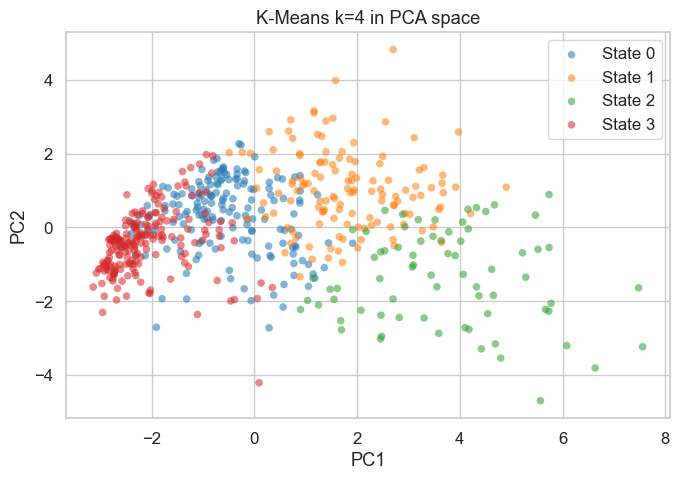

In [29]:
# K-Means scatter in PCA space
fig, ax = plt.subplots(figsize=(7, 5))
for s in range(K_CHOSEN):
    idx = meta[meta["kmeans_state"] == s].index
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               color=state_palette[s], label=f"State {s}",
               alpha=0.55, s=30, edgecolors="none")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"K-Means k={K_CHOSEN} in PCA space")
ax.legend(); plt.tight_layout(); plt.show()

In [30]:
# Diagnostic: impact of lex imputation on state assignments
import pandas as pd, numpy as np

lex_cols = [c for c in ALL_FEATURES if c.startswith("lex_")]
print(f"Lexical features in model: {lex_cols}")

# Which windows had missing lex data (before imputation)?
lex_missing = df[lex_cols].isna().any(axis=1)
n_imputed = lex_missing.sum()
print(f"\nWindows with ≥1 imputed lex feature: {n_imputed} / {len(df)} ({100*n_imputed/len(df):.1f}%)")

# State distribution for imputed vs non-imputed windows
print("\nState distribution — windows WITH real lex data:")
print(meta.loc[~lex_missing.values, "kmeans_state"].value_counts().sort_index())
print("\nState distribution — windows with IMPUTED lex data:")
print(meta.loc[lex_missing.values, "kmeans_state"].value_counts().sort_index())

# PCA loadings: how much do lex features contribute to the PCs used?
pc_loadings = pd.DataFrame(pca.components_[:n_pcs], columns=ALL_FEATURES,
                           index=[f"PC{i+1}" for i in range(n_pcs)])
lex_loading_magnitude = pc_loadings[lex_cols].abs().mean(axis=1)
nonlex_loading_magnitude = pc_loadings[[c for c in ALL_FEATURES if c not in lex_cols]].abs().mean(axis=1)
print(f"\nMean |loading| per PC — lex vs non-lex:")
for pc in pc_loadings.index:
    print(f"  {pc}: lex={lex_loading_magnitude[pc]:.3f}  non-lex={nonlex_loading_magnitude[pc]:.3f}")

Lexical features in model: ['lex_word_gini', 'lex_we_i_ratio', 'lex_turn_cohesion', 'lex_hedging_count']

Windows with ≥1 imputed lex feature: 122 / 568 (21.5%)

State distribution — windows WITH real lex data:
kmeans_state
0    164
1    121
2     68
3     93
Name: count, dtype: int64

State distribution — windows with IMPUTED lex data:
kmeans_state
0      6
1      9
2      4
3    103
Name: count, dtype: int64

Mean |loading| per PC — lex vs non-lex:
  PC1: lex=0.130  non-lex=0.201
  PC2: lex=0.199  non-lex=0.207
  PC3: lex=0.248  non-lex=0.131
  PC4: lex=0.254  non-lex=0.160
  PC5: lex=0.191  non-lex=0.163
  PC6: lex=0.213  non-lex=0.197
  PC7: lex=0.115  non-lex=0.156
  PC8: lex=0.259  non-lex=0.144
  PC9: lex=0.127  non-lex=0.160
  PC10: lex=0.242  non-lex=0.157


## 5. State Characterisation — What Does Each State Look Like?

We compute the Z-scored mean of each feature per state (relative to the overall mean) and display as a heatmap. This is the key interpretive step.

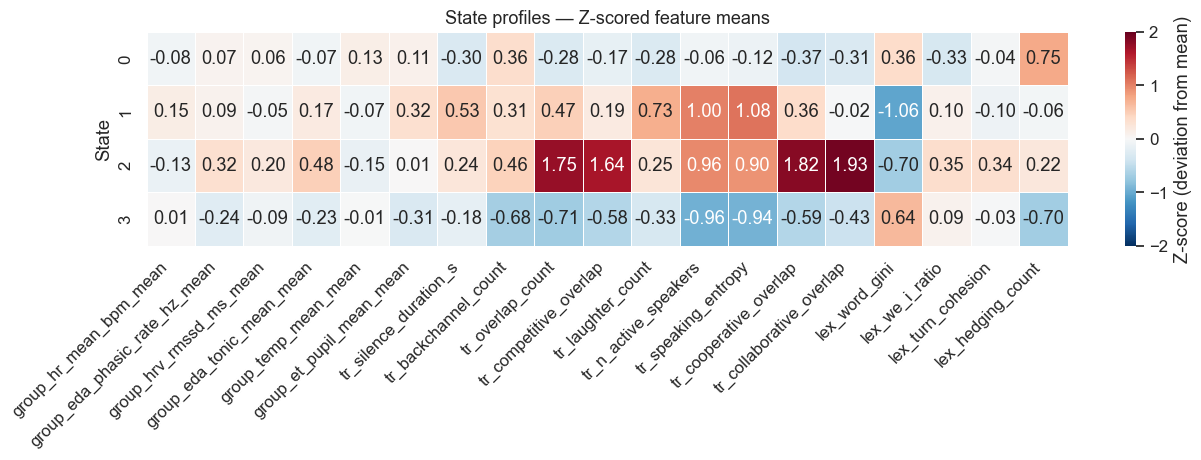


Raw mean values per state (unscaled):
              group_hr_mean_bpm_mean  group_eda_phasic_rate_hz_mean  group_hrv_rmssd_ms_mean  group_eda_tonic_mean_mean  group_temp_mean_mean  group_et_pupil_mean_mean  tr_silence_duration_s  tr_backchannel_count  tr_overlap_count  tr_competitive_overlap  tr_laughter_count  tr_n_active_speakers  tr_speaking_entropy  tr_cooperative_overlap  tr_collaborative_overlap  lex_word_gini  lex_we_i_ratio  lex_turn_cohesion  lex_hedging_count
kmeans_state                                                                                                                                                                                                                                                                                                                                                                                                                                       
0                             -0.127                          0.034                    0.

In [18]:
# Mean of Z-scored features per state (centroid in feature space)
feat_df = pd.DataFrame(X, columns=ALL_FEATURES)
feat_df["kmeans_state"] = meta["kmeans_state"].values

state_profiles = feat_df.groupby("kmeans_state")[ALL_FEATURES].mean()

fig, ax = plt.subplots(figsize=(max(10, len(ALL_FEATURES)*0.7), K_CHOSEN * 0.7 + 2))
sns.heatmap(
    state_profiles,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    annot=True, fmt=".2f", linewidths=0.5,
    ax=ax, cbar_kws={"label": "Z-score (deviation from mean)"}
)
ax.set_title("State profiles — Z-scored feature means", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("State")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print("\nRaw mean values per state (unscaled):")
raw_feat_df = pd.DataFrame(X_raw, columns=ALL_FEATURES)
raw_feat_df["kmeans_state"] = meta["kmeans_state"].values
print(raw_feat_df.groupby("kmeans_state")[ALL_FEATURES].mean().round(3).to_string())

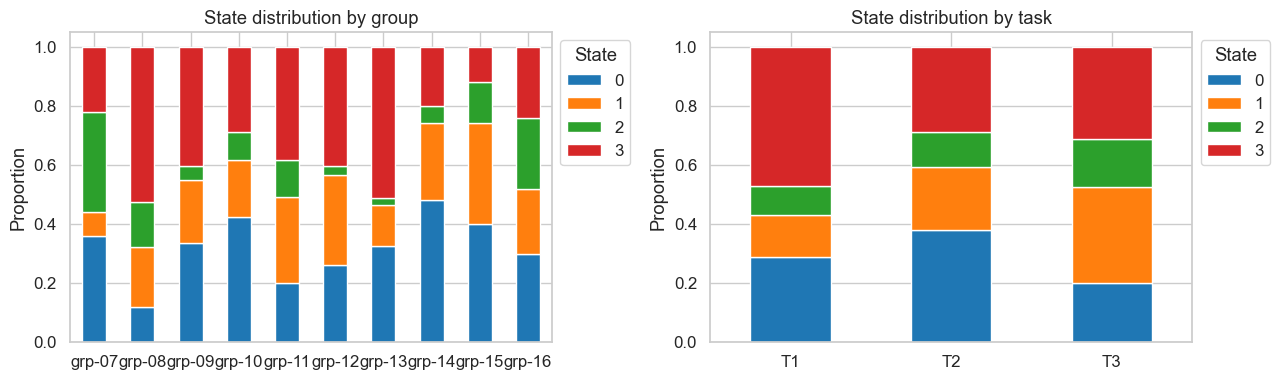

In [19]:
# State distribution by group and task
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pd.crosstab(meta["group_id"], meta["kmeans_state"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[0],
    color=state_palette, edgecolor="white"
)
axes[0].set_title("State distribution by group")
axes[0].set_xlabel(""); axes[0].set_ylabel("Proportion")
axes[0].legend(title="State", bbox_to_anchor=(1, 1))
axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(meta["task_id"], meta["kmeans_state"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1],
    color=state_palette, edgecolor="white"
)
axes[1].set_title("State distribution by task")
axes[1].set_xlabel(""); axes[1].set_ylabel("Proportion")
axes[1].legend(title="State", bbox_to_anchor=(1, 1))
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

## 6. Temporal State Trajectories

How do groups move through states over the course of each task? We plot the state sequence for each group × task.

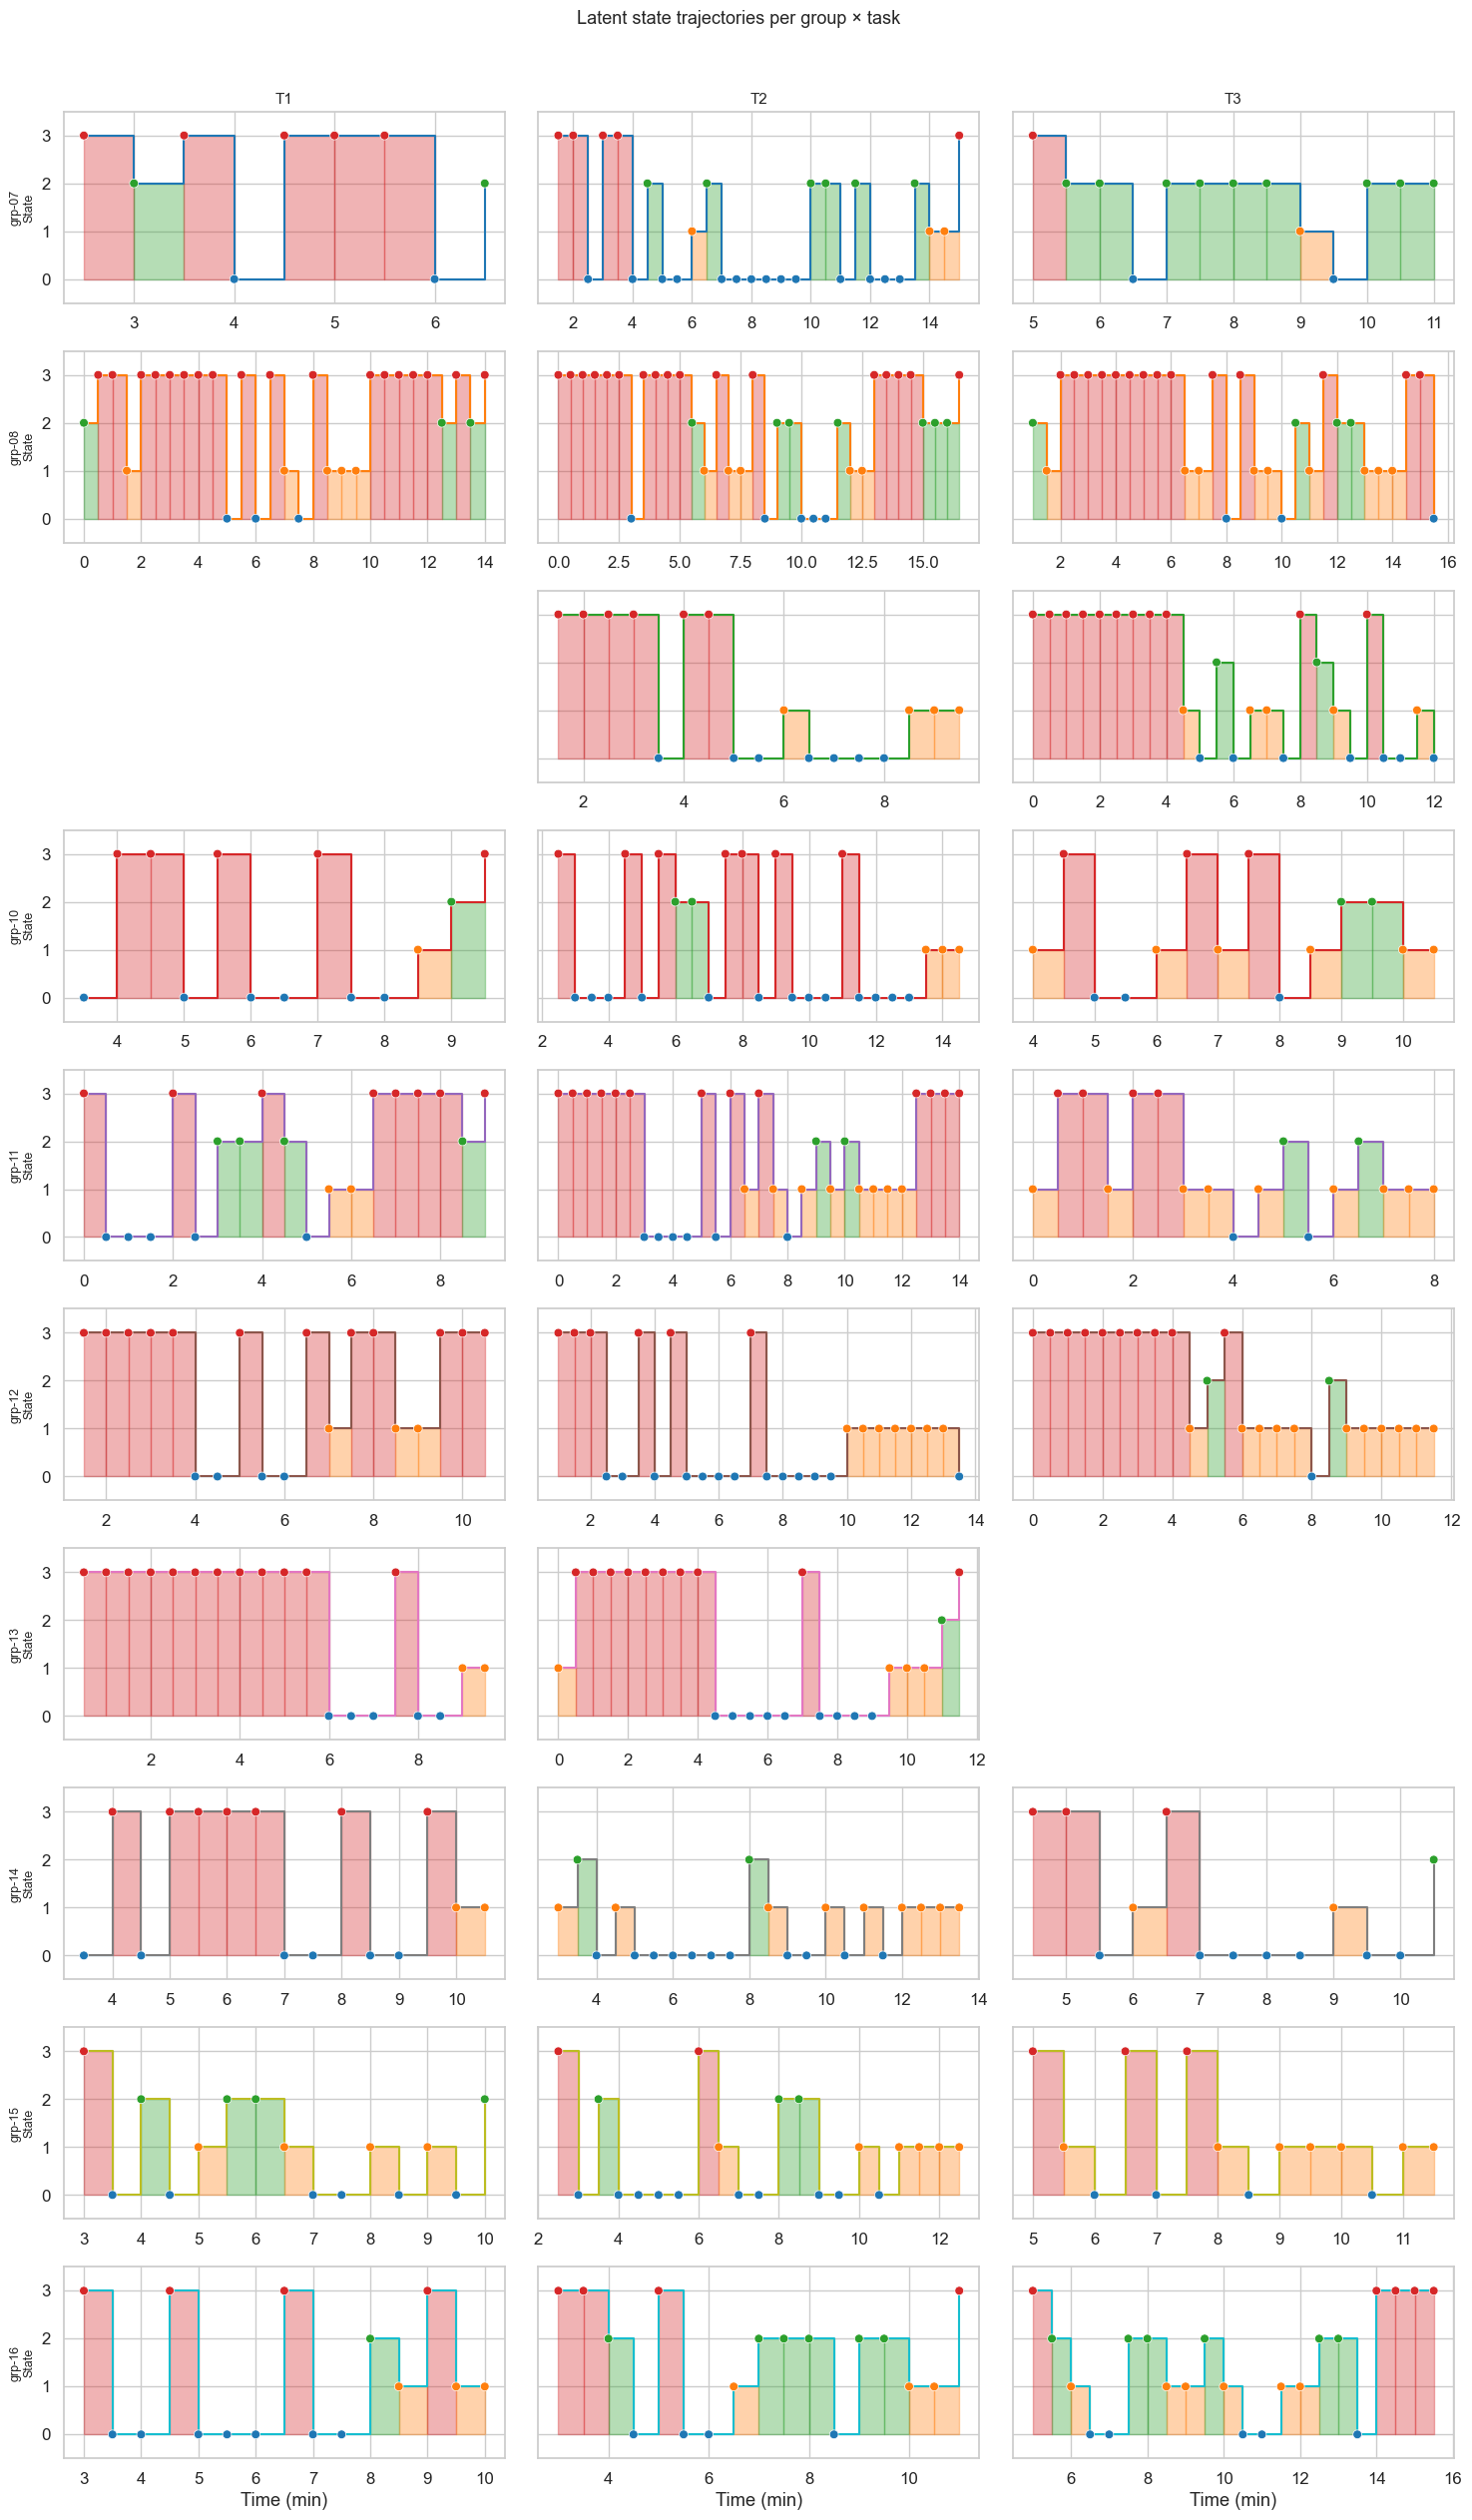

In [20]:
groups = sorted(meta["group_id"].unique())
tasks  = sorted(meta["task_id"].unique())

fig, axes = plt.subplots(len(groups), len(tasks),
                          figsize=(5 * len(tasks), 2.5 * len(groups)),
                          sharey=True)

for r, grp in enumerate(groups):
    for c, task in enumerate(tasks):
        ax = axes[r][c]
        subset = meta[(meta["group_id"] == grp) & (meta["task_id"] == task)].sort_values("window_index")
        if subset.empty:
            ax.set_visible(False)
            continue
        t = subset["window_start_s"] / 60  # minutes
        s = subset["kmeans_state"]
        # Fill under the state line with state colour
        for i in range(len(subset) - 1):
            ax.fill_between(
                [t.iloc[i], t.iloc[i+1]],
                [s.iloc[i], s.iloc[i]],
                alpha=0.35, color=state_palette[s.iloc[i]]
            )
        ax.step(t, s, where="post",
                color=GROUP_COLORS.get(grp, "gray"), lw=1.5)
        ax.scatter(t, s, c=[state_palette[st] for st in s],
                   s=40, zorder=3, edgecolors="white", linewidths=0.5)
        ax.set_ylim(-0.5, K_CHOSEN - 0.5)
        ax.set_yticks(range(K_CHOSEN))
        if c == 0: ax.set_ylabel(f"{grp}\nState", fontsize=9)
        if r == 0: ax.set_title(task, fontsize=11)
        if r == len(groups) - 1: ax.set_xlabel("Time (min)")

fig.suptitle("Latent state trajectories per group × task", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 7. Gaussian HMM (Temporal Model)

K-Means ignores the **temporal ordering** of windows — each window is clustered independently.
A Hidden Markov Model instead finds states that are **maximally consistent along the time axis**, which is more appropriate for group dynamics.

We use `sklearn.mixture.GaussianMixture` initialised with K-Means centroids, then apply **Viterbi-like sequential smoothing** to enforce temporal coherence. This is a lightweight substitute for `hmmlearn` (which requires C++ build tools on Windows).

In [21]:
# ── Viterbi decode with optimal HMM ─────────────────────────────────────────
hmm_model = hmm_models[K_CHOSEN]

hmm_labels = np.full(len(meta), -1, dtype=int)
for idx in seq_meta_idx:
    X_chunk = X_reduced[idx]
    path = hmm_model.decode(X_chunk)
    hmm_labels[idx] = path

# Remap state labels by frequency (state 0 = most common)
from collections import Counter
order = [s for s, _ in Counter(hmm_labels[hmm_labels >= 0]).most_common()]
remap = {o: n for n, o in enumerate(order)}
hmm_labels = np.array([remap.get(s, s) for s in hmm_labels])
meta["hmm_state"] = hmm_labels

print("HMM state distribution:")
print(meta["hmm_state"].value_counts().sort_index())
print(f"Log-likelihood: {hmm_model.log_likelihood_:.2f}")

print("\nLearned transition matrix (rows = from, cols = to):")
A = hmm_model.A_[np.ix_(order, order)]
print(pd.DataFrame(A.round(3),
                   columns=[f"->S{j}" for j in range(K_CHOSEN)],
                   index=[f"S{i}" for i in range(K_CHOSEN)]).to_string())

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(meta["kmeans_state"], meta["hmm_state"])
print(f"\nAdjusted Rand Index (KMeans vs HMM): {ari:.3f}")


HMM state distribution:
hmm_state
0    258
1    179
2     70
3     61
Name: count, dtype: int64
Log-likelihood: -8255.74

Learned transition matrix (rows = from, cols = to):
     ->S0   ->S1   ->S2   ->S3
S0  0.925  0.006  0.026  0.043
S1  0.000  0.963  0.000  0.037
S2  0.027  0.000  0.940  0.033
S3  0.213  0.077  0.000  0.710

Adjusted Rand Index (KMeans vs HMM): 0.074


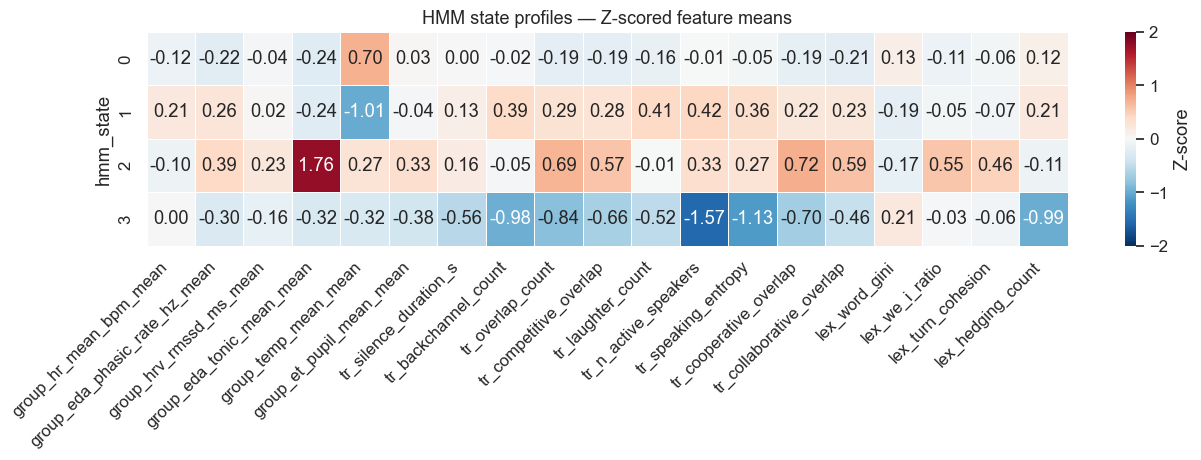

In [22]:
# HMM state profiles
feat_df2 = pd.DataFrame(X, columns=ALL_FEATURES)
feat_df2["hmm_state"] = meta["hmm_state"].values

hmm_profiles = feat_df2.groupby("hmm_state")[ALL_FEATURES].mean()

fig, ax = plt.subplots(figsize=(max(10, len(ALL_FEATURES)*0.7), K_CHOSEN * 0.7 + 2))
sns.heatmap(
    hmm_profiles,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    annot=True, fmt=".2f", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Z-score"}
)
ax.set_title("HMM state profiles — Z-scored feature means", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

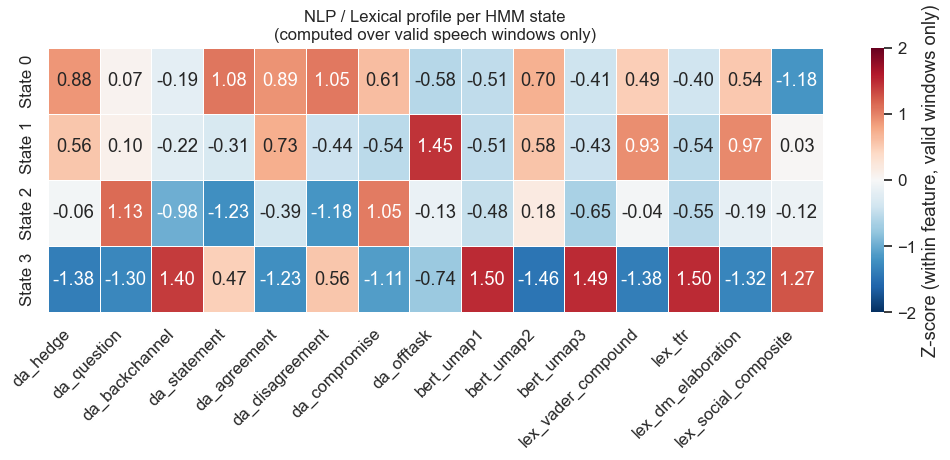


Window counts used per state for NLP characterization:
  State 0: 253/258 windows have NLP data
  State 1: 179/179 windows have NLP data
  State 2: 69/70 windows have NLP data
  State 3: 13/61 windows have NLP data


In [23]:
# Post-hoc NLP characterization: mean over VALID (non-NaN) windows per state
# No imputation -- silence windows are simply excluded from each NLP mean.
char_cols = [c for c in NLP_CHAR_FEATURES if c in df.columns]
if char_cols:
    char_df = df.copy()
    char_df["hmm_state"] = meta["hmm_state"].values
    state_nlp = {}
    for s in range(K_CHOSEN):
        sub = char_df[char_df["hmm_state"] == s][char_cols].dropna(how="all")
        state_nlp[s] = sub.mean()
    nlp_profile = pd.DataFrame(state_nlp).T
    nlp_profile.index = [f"State {s}" for s in range(K_CHOSEN)]

    fig, ax = plt.subplots(figsize=(max(10, len(char_cols)*0.7), K_CHOSEN*0.7+2))
    sns.heatmap(
        nlp_profile.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9)),
        cmap="RdBu_r", center=0, vmin=-2, vmax=2,
        annot=True, fmt=".2f", linewidths=0.5, ax=ax,
        cbar_kws={"label": "Z-score (within feature, valid windows only)"}
    )
    ax.set_title("NLP / Lexical profile per HMM state\n(computed over valid speech windows only)", fontsize=12)
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

    print("\nWindow counts used per state for NLP characterization:")
    for s in range(K_CHOSEN):
        n_valid = char_df[char_df["hmm_state"] == s][char_cols[0]].notna().sum()
        n_total = (char_df["hmm_state"] == s).sum()
        print(f"  State {s}: {n_valid}/{n_total} windows have NLP data")
else:
    print("No NLP characterization features found in dataframe.")


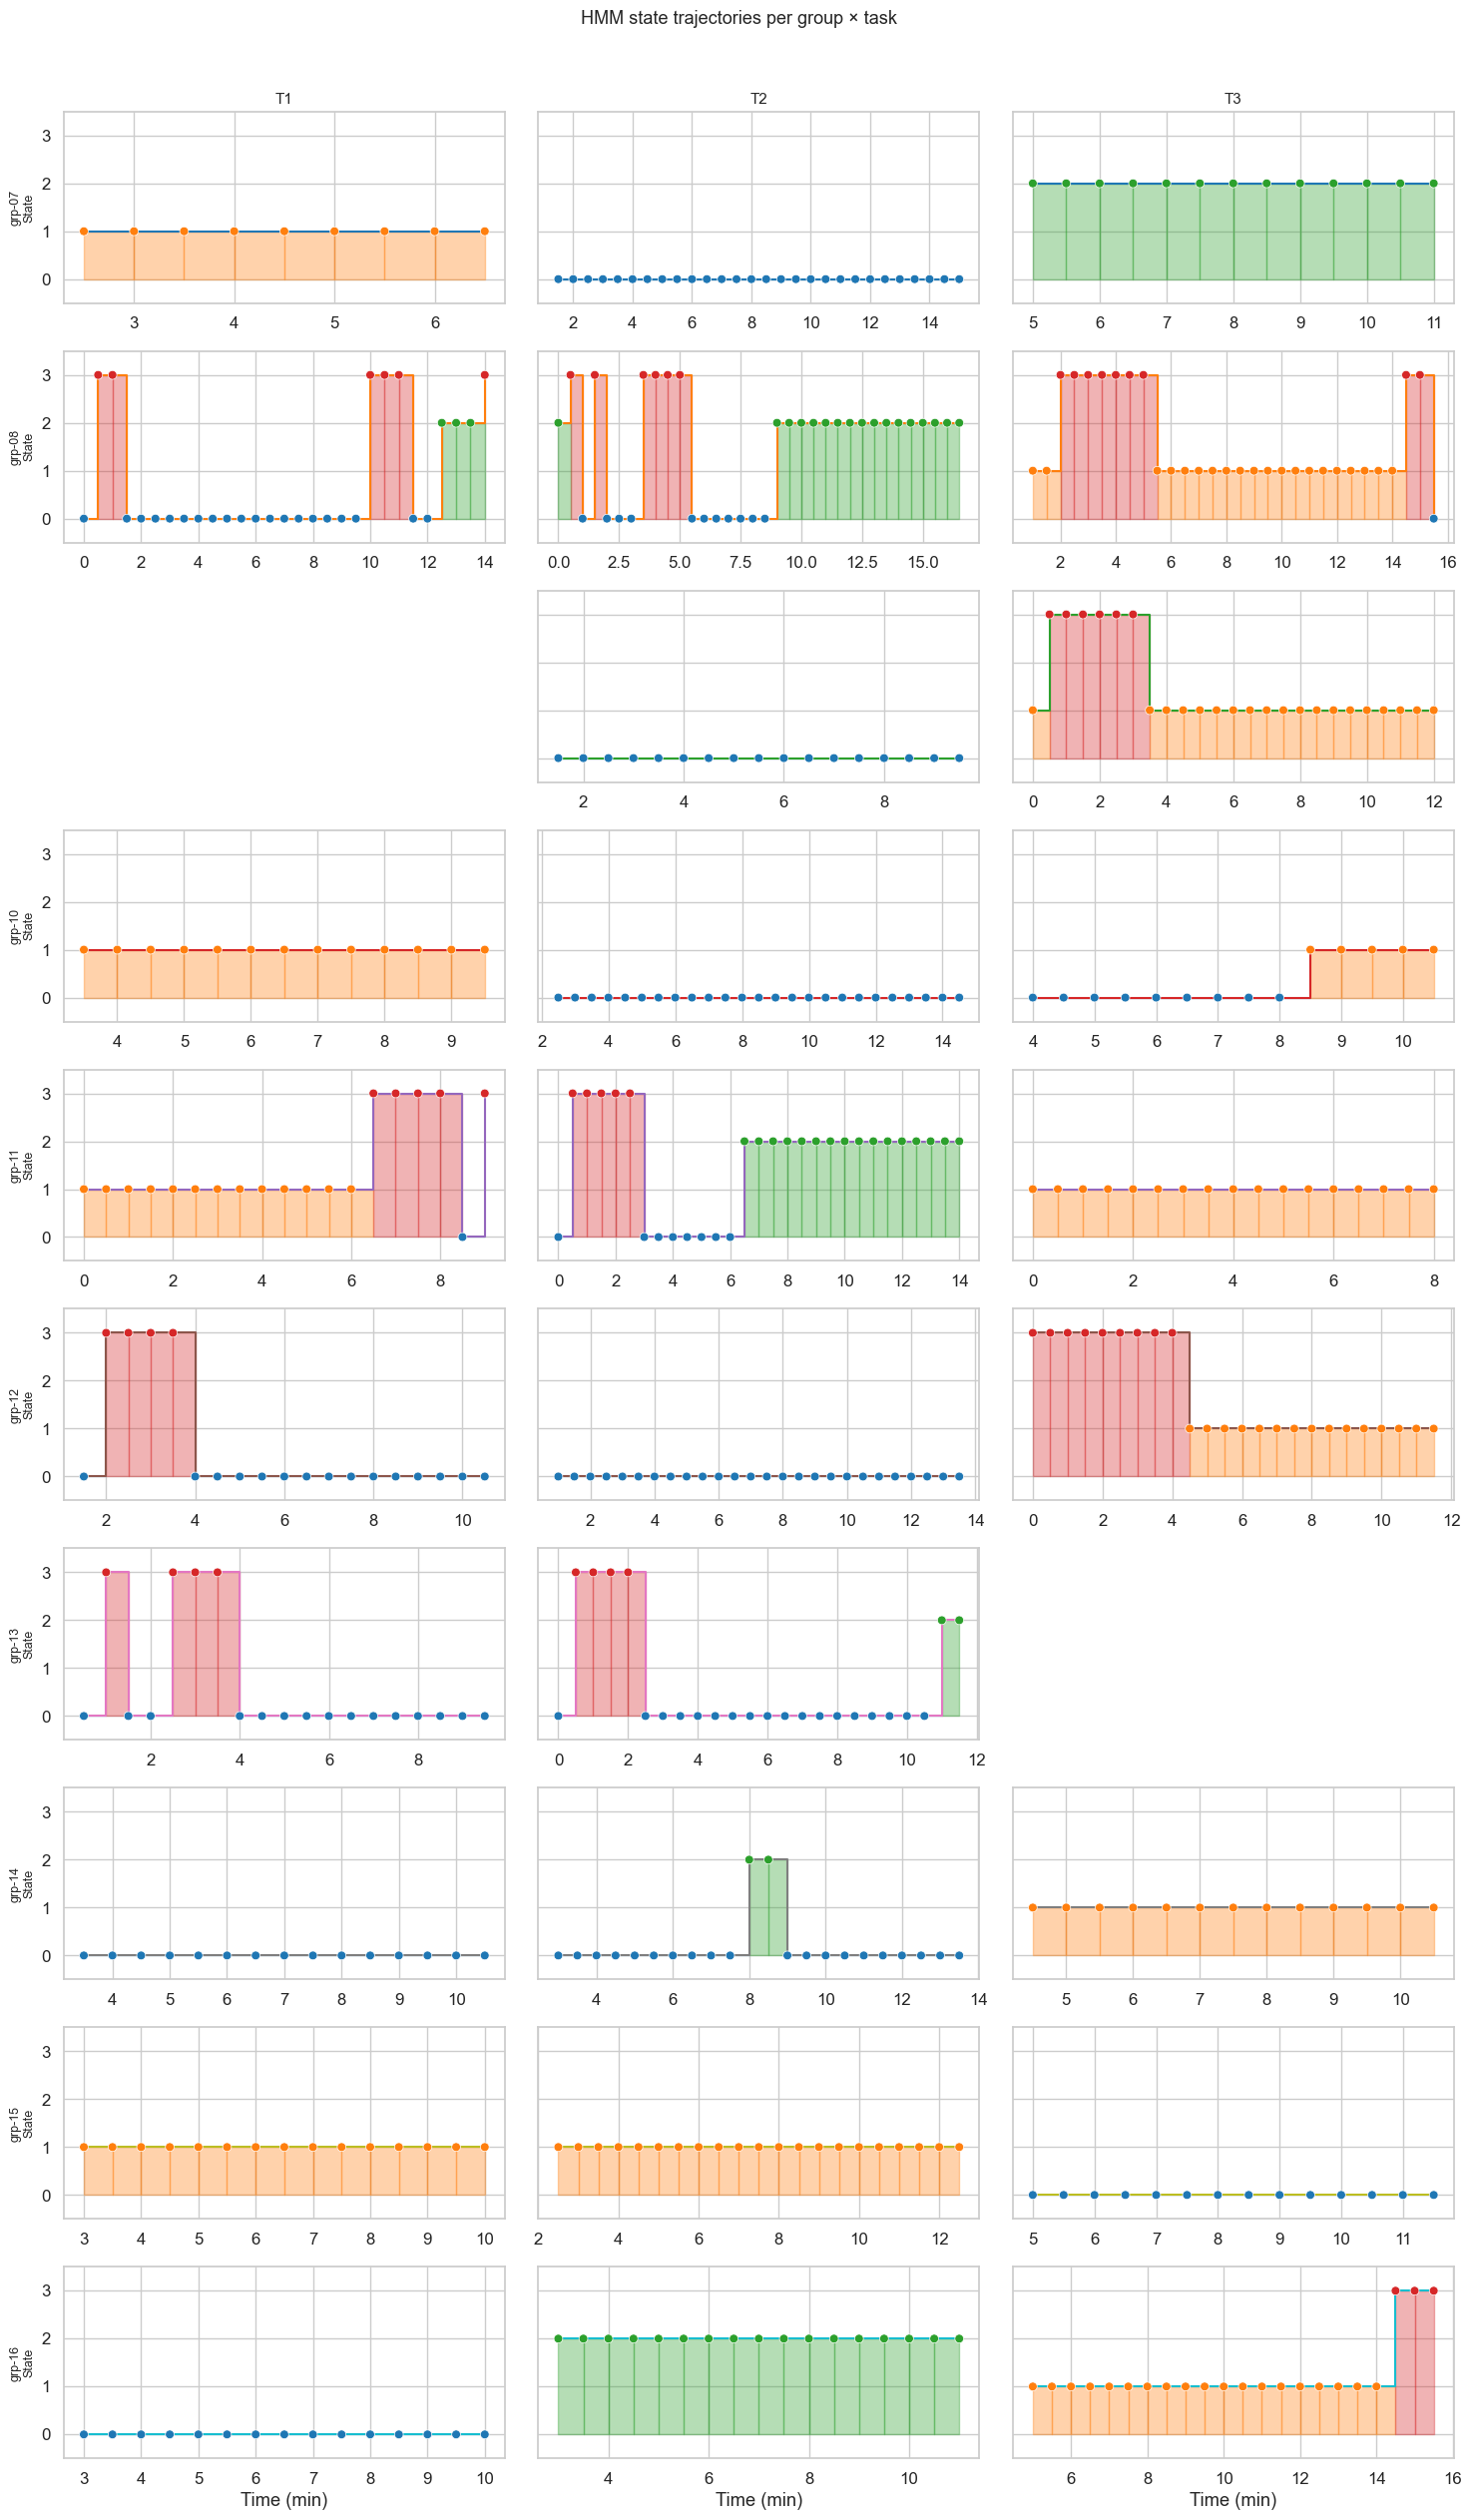

In [24]:
# HMM temporal trajectories
fig, axes = plt.subplots(len(groups), len(tasks),
                          figsize=(5 * len(tasks), 2.5 * len(groups)),
                          sharey=True)

for r, grp in enumerate(groups):
    for c, task in enumerate(tasks):
        ax = axes[r][c]
        subset = meta[(meta["group_id"] == grp) & (meta["task_id"] == task)].sort_values("window_index")
        if subset.empty:
            ax.set_visible(False)
            continue
        t = subset["window_start_s"] / 60
        s = subset["hmm_state"]
        for i in range(len(subset) - 1):
            ax.fill_between([t.iloc[i], t.iloc[i+1]], [s.iloc[i], s.iloc[i]],
                            alpha=0.35, color=state_palette[s.iloc[i]])
        ax.step(t, s, where="post", color=GROUP_COLORS.get(grp, "gray"), lw=1.5)
        ax.scatter(t, s, c=[state_palette[st] for st in s],
                   s=40, zorder=3, edgecolors="white", linewidths=0.5)
        ax.set_ylim(-0.5, K_CHOSEN - 0.5)
        ax.set_yticks(range(K_CHOSEN))
        if c == 0: ax.set_ylabel(f"{grp}\nState", fontsize=9)
        if r == 0: ax.set_title(task, fontsize=11)
        if r == len(groups) - 1: ax.set_xlabel("Time (min)")

fig.suptitle("HMM state trajectories per group × task", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 8. Validation Against Self-Report

We compute the **proportion of windows in each state** per group × task, then correlate those proportions with the post-task self-report items (engagement, voice_inclusion, satisfaction, VAD).

A significant correlation means the state captures something behaviourally meaningful — it's not just a noise cluster.

In [25]:
state_col = 'hmm_state'

# Categorical + observed=False ensures all K states appear as columns even if absent
meta[state_col] = pd.Categorical(meta[state_col], categories=range(K_CHOSEN))

state_props = (
    meta.groupby(['group_id', 'task_id', state_col], observed=False)
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
    .reset_index()
)
state_props.columns = ['group_id', 'task_id'] + [f'state_{s}_prop' for s in range(K_CHOSEN)]

val_df = pd.merge(state_props, selfreport, on=['group_id', 'task_id'], how='inner')
print(f'Validation dataset: {len(val_df)} group x task rows')
val_df.head()


Validation dataset: 28 group x task rows


,group_id,task_id,state_0_prop,state_1_prop,state_2_prop,state_3_prop,vad_valence_mean,vad_valence_std,vad_arousal_mean,vad_arousal_std,...,satisfaction_mean,cooperative_mean,trust_angle_mean,trust_front_mean,trust_next_mean,confidence_mean,psych_safety_mean,fairness_mean,idea_quality_mean,idea_diversity_mean
0,grp-07,T1,0.000000,1.0,0.000000,0.000000,7.625,1.109,7.125,1.181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,grp-07,T2,1.000000,0.0,0.000000,0.000000,7.333,2.055,7.750,0.500,...,5.25,3.75,4.0,6.00,4.5,NaN,NaN,NaN,NaN,NaN
2,grp-07,T3,0.000000,0.0,1.000000,0.000000,8.000,0.816,7.625,1.493,...,6.00,NaN,NaN,NaN,NaN,6.0,6.25,6.5,5.75,5.5
3,grp-08,T1,0.689655,0.0,0.103448,0.206897,6.583,0.500,5.083,2.754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,grp-08,T2,0.323529,0.0,0.500000,0.176471,6.444,0.096,5.167,2.363,...,5.50,3.75,4.0,6.25,5.0,NaN,NaN,NaN,NaN,NaN


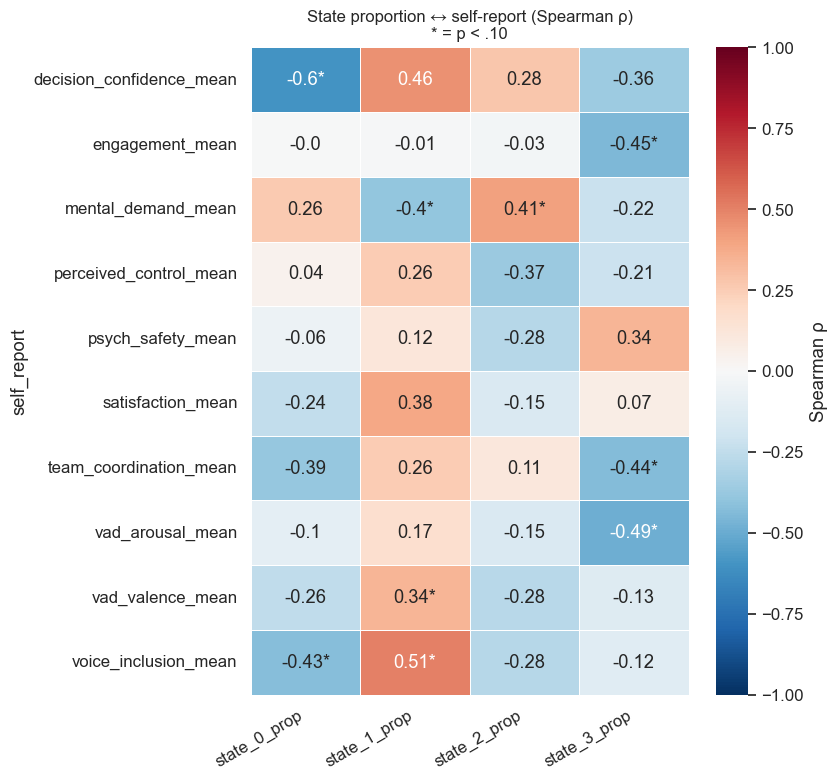

In [26]:
# Spearman correlations: each state proportion vs each self-report item
state_prop_cols = [f"state_{s}_prop" for s in range(K_CHOSEN)]

selfreport_items = [
    "vad_valence_mean", "vad_arousal_mean",
    "engagement_mean", "voice_inclusion_mean",
    "satisfaction_mean", "mental_demand_mean",
    "team_coordination_mean", "psych_safety_mean",
    "decision_confidence_mean", "perceived_control_mean",
]
selfreport_items = [c for c in selfreport_items if c in val_df.columns]

corr_rows = []
for sp in state_prop_cols:
    for sr in selfreport_items:
        pair = val_df[[sp, sr]].dropna()
        if len(pair) < 4:
            continue
        r, p = spearmanr(pair[sp], pair[sr])
        corr_rows.append({"state_prop": sp, "self_report": sr,
                          "rho": round(r, 3), "p": round(p, 3)})

corr_df = pd.DataFrame(corr_rows)

if not corr_df.empty:
    pivot = corr_df.pivot(index="self_report", columns="state_prop", values="rho")
    p_pivot = corr_df.pivot(index="self_report", columns="state_prop", values="p")
    annot = pivot.round(2).astype(str).where(p_pivot >= 0.10, pivot.round(2).astype(str) + "*")

    fig, ax = plt.subplots(figsize=(K_CHOSEN * 1.6 + 2, len(selfreport_items) * 0.6 + 2))
    sns.heatmap(
        pivot, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        annot=annot, fmt="", linewidths=0.5, ax=ax,
        cbar_kws={"label": "Spearman ρ"}
    )
    ax.set_title("State proportion ↔ self-report (Spearman ρ)\n* = p < .10", fontsize=12)
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()
else:
    print("Not enough data for correlations — check that self-report items exist.")

## 9. Perceived vs Behavioural Dominance

Each participant rated how dominant every other participant was (`dominance_p1–p4`).  
We compare that against **behavioural speaking share** from the transcripts — a sanity check that the discovered states reflect real social dynamics.

In [27]:
# Behavioural vs perceived dominance — requires transcript_participant_task.tsv
_tpt_path = ROOT / "features" / "transcript_participant_task.tsv"
if not _tpt_path.exists():
    print("transcript_participant_task.tsv not found — skipping dominance comparison.")
    print("(This is a non-critical sanity check; safe to skip.)")
else:
    transcript_pt = pd.read_csv(_tpt_path, sep="\t")
    behav_dom = transcript_pt[transcript_pt["task_id"].isin(["T1","T2","T3"])].copy()
    perc_dom_cols = [c for c in selfreport.columns if c.startswith("perceived_dominance_")]
    print("Perceived dominance columns:", perc_dom_cols)
    if perc_dom_cols:
        perc_long = selfreport[["group_id", "task_id"] + perc_dom_cols].melt(
            id_vars=["group_id", "task_id"], value_vars=perc_dom_cols,
            var_name="participant_id", value_name="perceived_dominance"
        )
        perc_long["participant_id"] = perc_long["participant_id"].str.replace("perceived_dominance_", "")
        merged_dom = pd.merge(
            behav_dom[["group_id", "task_id", "participant_id", "speaking_share"]],
            perc_long, on=["group_id", "task_id", "participant_id"]
        ).dropna()
        if len(merged_dom) >= 4:
            fig, ax = plt.subplots(figsize=(6, 5))
            for pid, sub in merged_dom.groupby("participant_id"):
                ax.scatter(sub["speaking_share"], sub["perceived_dominance"], label=pid, alpha=0.75, s=60)
            r, p = spearmanr(merged_dom["speaking_share"], merged_dom["perceived_dominance"])
            ax.set_xlabel("Behavioural speaking share")
            ax.set_ylabel("Perceived dominance (peer-rated)")
            ax.set_title(f"Behavioural vs perceived dominance\nSpearman ρ = {r:.2f}, p = {p:.3f}")
            ax.legend(title="Participant", markerscale=1.2)
            plt.tight_layout(); plt.show()
    else:
        print("No perceived dominance columns in self-report.")

transcript_participant_task.tsv not found — skipping dominance comparison.
(This is a non-critical sanity check; safe to skip.)


## 10. Summary & Next Steps

**What to look for in the results:**

| State profile | Likely interpretation |
|---|---|
| High conflict-overlap ratio with low cooperative overlap | **Overt contention / floor competition** |
| High cooperative + collaborative overlap, high speaking entropy | **Active co-construction / engaged deliberation** |
| High needs_review overlap, elevated arousal markers | **Ambiguous pressure state (review labels/context)** |
| Low overlap, high silence, lower speaking entropy | **Low-energy coordination / temporary disengagement** |

**Next steps:**
- Re-run this notebook with `features_after/collective_window_features.tsv` to align with revised overlap labels
- Compare state stability under within-session normalization (group-centered z-scores)
- Treat `tr_needs_review_overlap` as a sensitivity feature and run a manual adjudication pass
- Report task-conditioned state prevalence and transitions (T1 vs T2 vs T3)

## 10. Export State Proportions for Prediction Model


In [28]:
# Export per-group×task HMM state proportions for use in effectiveness_prediction_models.ipynb
state_col = 'hmm_state'
if state_col not in meta.columns:
    state_col = 'kmeans_state'
    print('Using K-Means states (HMM not available)')

# Categorical + observed=False ensures all K states appear as columns even if absent
meta[state_col] = pd.Categorical(meta[state_col], categories=range(K_CHOSEN))

state_props = (
    meta.groupby(['group_id', 'task_id', state_col], observed=False)
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
    .reset_index()
)
state_props.columns = (['group_id', 'task_id'] +
                        [f'S{s}_pct' for s in range(K_CHOSEN)])

out_path = ROOT / 'analysis' / 'results' / 'hmm_state_proportions_expanded.tsv'
state_props.to_csv(out_path, sep='\t', index=False)
print(f'Saved state proportions: {len(state_props)} rows → {out_path}')
print(state_props.head())

# Also export proportion of silent (individual-work) windows per group x task
sil_out = ROOT / 'analysis' / 'results' / 'hmm_silent_window_props.tsv'
silence_props.to_csv(sil_out, sep='\t', index=False)
print(f'Saved silence proportions: {len(silence_props)} rows -> {sil_out}')
print(silence_props.describe().round(3))


Saved state proportions: 28 rows → ..\analysis\results\hmm_state_proportions_expanded.tsv
  group_id task_id    S0_pct  S1_pct    S2_pct    S3_pct
0   grp-07      T1  0.000000     1.0  0.000000  0.000000
1   grp-07      T2  1.000000     0.0  0.000000  0.000000
2   grp-07      T3  0.000000     0.0  1.000000  0.000000
3   grp-08      T1  0.689655     0.0  0.103448  0.206897
4   grp-08      T2  0.323529     0.0  0.500000  0.176471
Saved silence proportions: 28 rows -> ..\analysis\results\hmm_silent_window_props.tsv
       prop_silent_windows
count               28.000
mean                 0.289
std                  0.071
min                  0.135
25%                  0.272
50%                  0.300
75%                  0.316
max                  0.438
